<a href="https://colab.research.google.com/github/Aditalbqhr/Water-Quality-Classification-Using-XGBoost-ADASYN/blob/main/LulusCepatBanget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import Library**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

**Upload Dan Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('IoTPond10.csv')  # sesuaikan nama file jika beda
df.head()

Saving IoTPond10.csv to IoTPond10 (13).csv


,created_at,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Length,Weight
0,2021-06-25 15:48:59 CET,1,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
1,2021-06-25 15:49:19 CET,2,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
2,2021-06-25 15:50:16 CET,3,27.1250,100,0.0,6.01411,0.0,139,50,13.45,27.6
3,2021-06-25 15:51:50 CET,4,27.3125,100,0.0,6.03227,0.0,131,50,13.45,27.6
4,2021-06-25 15:52:10 CET,5,27.2500,100,0.0,6.03681,0.0,133,50,13.45,27.6


**Rename Column**

In [ ]:
df.rename(columns={
    'TEMPERATURE': 'Temperature',
    'TURBIDITY': 'Turbidity',
    'DISOLVED OXYGEN': 'DO',
    'AMMONIA': 'Ammonia',
    'NITRATE': 'Nitrate'
}, inplace=True)

df.columns

Index(['created_at', 'entry_id', 'Temperature', 'Turbidity', 'DO', 'pH',
       'Ammonia', 'Nitrate', 'Population', 'Length', 'Weight'],
      dtype='object')

**Cleaning Data**

In [ ]:
# =========================
# CLEANING DATA (FIX)
# =========================

# 1. Replace infinity
df = df.replace([np.inf, -np.inf], np.nan)

# 2. Pilih hanya kolom numerik
num_cols = df.select_dtypes(include=[np.number]).columns

# 3. Isi missing value hanya di kolom numerik
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 4. Clip hanya kolom numerik (INI YANG PENTING)
df[num_cols] = df[num_cols].clip(lower=-1e6, upper=1e6)

# 5. Cek hasil
print("Cek NaN:")
print(df[num_cols].isnull().sum())

Cek NaN:
entry_id       0
Temperature    0
Turbidity      0
DO             0
pH             0
Ammonia        0
Nitrate        0
Population     0
Length         0
Weight         0
dtype: int64


**Labelling**

In [ ]:
def label_kualitas(row):
    score = 0

    if 6.5 <= row['pH'] <= 8.5:
        score += 1

    if row['DO'] > 5:
        score += 1

    if 25 <= row['Temperature'] <= 30:
        score += 1

    if row['Ammonia'] < 0.5:
        score += 1

    if row['Nitrate'] < 50:
        score += 1

    if score >= 4:
        return 'Baik'
    elif score >= 2:
        return 'Sedang'
    else:
        return 'Buruk'

df['kualitas_air'] = df.apply(label_kualitas, axis=1)

df[['pH','DO','Temperature','kualitas_air']].head()

,pH,DO,Temperature,kualitas_air
0,15.45166,0.0,-127.0000,Sedang
1,15.45166,0.0,-127.0000,Sedang
2,6.01411,0.0,27.1250,Sedang
3,6.03227,0.0,27.3125,Sedang
4,6.03681,0.0,27.2500,Sedang


**Distribusi Kelas**

In [ ]:
print(df['kualitas_air'].value_counts())

kualitas_air
Sedang    508
Buruk      88
Baik       24
Name: count, dtype: int64


**Pemilihan Fitur**

In [ ]:
# ❗ HANYA pakai fitur yang TIDAK dipakai saat labeling
X = df[['Turbidity', 'Population', 'Length', 'Weight']]

y = df['kualitas_air']

**Encoding Label**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

**Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from imblearn.over_sampling import ADASYN
from collections import Counter

adasyn = ADASYN(n_neighbors=2, random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

print("Sebelum:", Counter(y_train))
print("Sesudah:", Counter(y_train_res))

Sebelum: Counter({np.int64(2): 406, np.int64(1): 71, np.int64(0): 19})
Sesudah: Counter({np.int64(2): 406, np.int64(1): 400, np.int64(0): 399})


In [ ]:
import pandas as pd

print("Sebelum ADASYN:")
print(pd.Series(y_train).value_counts())

print("\nSesudah ADASYN:")
print(pd.Series(y_train_res).value_counts())

Sebelum ADASYN:
2    406
1     71
0     19
Name: count, dtype: int64

Sesudah ADASYN:
2    406
1    400
0    399
Name: count, dtype: int64


**Model XGBoost**

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

**Evaluasi Model**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.41      0.88      0.56        17
           2       0.95      0.39      0.56       102

    accuracy                           0.48       124
   macro avg       0.49      0.76      0.44       124
weighted avg       0.84      0.48      0.54       124


Confusion Matrix:
[[ 5  0  0]
 [ 0 15  2]
 [40 22 40]]


In [ ]:
y_pred_label = le.inverse_transform(y_pred)
y_test_label = le.inverse_transform(y_test)

print("Contoh prediksi:")
print(y_pred_label[:10])

Contoh prediksi:
['Sedang' 'Baik' 'Baik' 'Sedang' 'Baik' 'Baik' 'Baik' 'Buruk' 'Sedang'
 'Buruk']


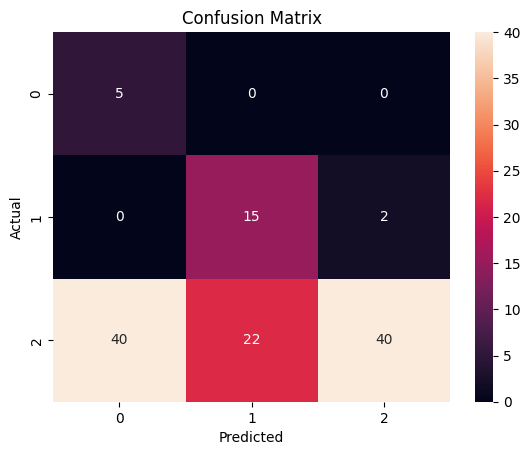

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()